## Import

In [1]:
import pandas as pd
import numpy as np

import geopandas as gpd
import fiona
from scipy.spatial import KDTree

import matplotlib.pyplot as plt
import seaborn as sns

import libpysal as lps
from esda.moran import Moran_Local
from splot.esda import lisa_cluster

import mapclassify as mc
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import statsmodels.formula.api as smf
from statsmodels.stats.stattools import durbin_watson
import spreg

import warnings
warnings.filterwarnings('ignore')

## Standardize CRS

In [2]:
target_crs = 'EPSG:27700'

culture_points = gpd.read_file('datasets/CulturalInfrastructureMap.gpkg').to_crs(target_crs)
town_centres = gpd.read_file('datasets/Town_Centres_Boundaries.gpkg').to_crs(target_crs)
wards = gpd.read_file('datasets/London wards/London_Ward.shp').to_crs(target_crs)
ptal = gpd.read_file('datasets/2015 PTALs Grid Values/2015 PTALs Contours 280515.TAB').to_crs(target_crs)

print(f"Cultural Infrastructure Map CRS: {culture_points.crs}")
print(f"Town Centres Boundaries CRS: {town_centres.crs}")
print(f"Wards Boundaries CRS: {wards.crs}")
print(f"PTALs CRS: {ptal.crs}")

Cultural Infrastructure Map CRS: EPSG:27700
Town Centres Boundaries CRS: EPSG:27700
Wards Boundaries CRS: EPSG:27700
PTALs CRS: EPSG:27700


### Visual check

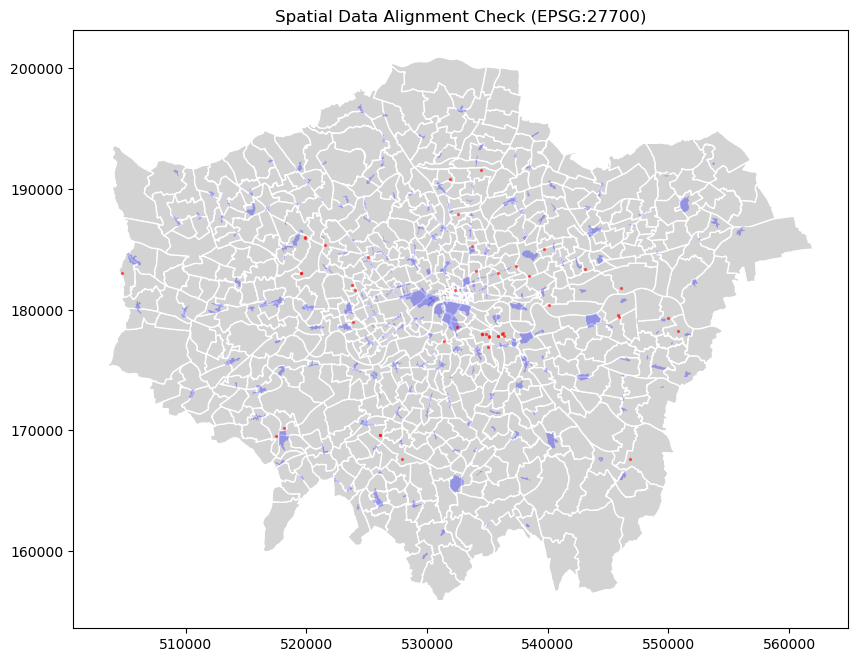

In [3]:
fig, ax = plt.subplots(figsize=(10, 10))
wards.plot(ax=ax, color='lightgrey', edgecolor='white')
town_centres.plot(ax=ax, color='blue', alpha=0.3)
culture_points.plot(ax=ax, color='red', markersize=2, alpha=0.5)
plt.title("Spatial Data Alignment Check (EPSG:27700)")
plt.show()

## Spatial Cleaning

### Fixing Layer

In [4]:
old_path = 'datasets/CulturalInfrastructureMap.gpkg'
new_path = 'datasets/CulturalInfrastructureMap_Updated.gpkg'
target_crs = 'EPSG:27700'

layers = fiona.listlayers(old_path)
for i, layer in enumerate(layers):
    if layer == 'Cinemas':
        df = gpd.read_file(old_path, layer=layer, ignore_geometry=True)
        gdf = gpd.GeoDataFrame(
            df, 
            geometry=gpd.points_from_xy(pd.to_numeric(df['longitude'], errors='coerce'), 
                                        pd.to_numeric(df['latitude'], errors='coerce')),
            crs=target_crs
        ).dropna(subset=['geometry'])
        print(f"Correction needed! Layer: {layer}")
    else:
        gdf = gpd.read_file(old_path, layer=layer).to_crs(target_crs)
        print(f"No correction needed! Layer: {layer}")

    write_mode = 'w' if i == 0 else 'a'
    gdf.to_file(new_path, layer=layer, driver="GPKG", mode=write_mode)

print(f"\nSave as：{new_path}")

No correction needed! Layer: Set_and_exhibition_building
No correction needed! Layer: Skate_Parks
No correction needed! Layer: Textile_design
No correction needed! Layer: Theatre_rehearsal_studio
No correction needed! Layer: Theatres
No correction needed! Layer: Commercial_galleries
No correction needed! Layer: Community_centres
No correction needed! Layer: Creative_coworking_desk_space
No correction needed! Layer: Creative_workspaces
No correction needed! Layer: Dance_performance_venues
No correction needed! Layer: Dance_rehearsal_studios
No correction needed! Layer: Fashion_and_design
No correction needed! Layer: Heritage_at_risk
No correction needed! Layer: Jewellery_design
No correction needed! Layer: Large_media_production_studios
No correction needed! Layer: Legal_street_art_walls
No correction needed! Layer: LGBT_night_time_venues
No correction needed! Layer: Libraries
No correction needed! Layer: Listed_buildings
No correction needed! Layer: Live_in_artists_workspace
No correct

In [5]:
culture_path = 'datasets/CulturalInfrastructureMap_Updated.gpkg'
wards_path = 'datasets/London wards/London_Ward.shp'
target_crs = 'EPSG:27700'

wards = gpd.read_file(wards_path).to_crs(target_crs)
london_boundary = wards.dissolve()

all_points = []
for layer in fiona.listlayers(culture_path):
    gdf = gpd.read_file(culture_path, layer=layer).to_crs(target_crs)
    gdf['Category'] = layer
    all_points.append(gdf)
all_points = gpd.GeoDataFrame(pd.concat(all_points, ignore_index=True), crs=target_crs)

print(f"Total number of points: {len(all_points)} ")
print(f"Total layers: {len(layers)}\n")

layer_names = []
layer_counts = []
total_original = 0
total_cleaned = 0

print("List of layer names and counts:")
for i, layer in enumerate(layers):
    gdf = gpd.read_file(culture_path, layer=layer).to_crs(target_crs)
    total_original += len(gdf)
    
    gdf_cleaned = gdf.clip(london_boundary)
    count = len(gdf_cleaned)
    total_cleaned += count
    
    layer_names.append(layer)
    layer_counts.append(count)
    
    print(f"{i+1}. {layer}: {count}")

print(f"Original total points: {total_original}")
print(f"Cleaned total points: {total_cleaned}")
print(f"Removed {total_original - total_cleaned} points outside London.")

Total number of points: 30001 
Total layers: 35

List of layer names and counts:
1. Set_and_exhibition_building: 46
2. Skate_Parks: 50
3. Textile_design: 81
4. Theatre_rehearsal_studio: 118
5. Theatres: 264
6. Commercial_galleries: 306
7. Community_centres: 903
8. Creative_coworking_desk_space: 50
9. Creative_workspaces: 84
10. Dance_performance_venues: 190
11. Dance_rehearsal_studios: 265
12. Fashion_and_design: 158
13. Heritage_at_risk: 746
14. Jewellery_design: 315
15. Large_media_production_studios: 5
16. Legal_street_art_walls: 6
17. LGBT_night_time_venues: 75
18. Libraries: 342
19. Listed_buildings: 19242
20. Live_in_artists_workspace: 8
21. Makerspaces: 74
22. Making_and_manufacturing: 43
23. Museums_and_public_galleries: 163
24. Music_office_based_businesses: 304
25. Music_recording_studios: 71
26. Music_rehearsal_studios: 79
27. Music_venues_all: 797
28. Music_venues_grassroots: 100
29. Outdoor_spaces_for_cultural_use: 17
30. Prop_and_costume_making: 53
31. Pubs: 4098
32. Arch

## Calculate ward area and cultural infrastructures density

In [6]:
wards['area_sqkm'] = wards.geometry.area / 1e6

# Spatial Join
joined = gpd.sjoin(all_points, wards[['GSS_CODE', 'NAME', 'geometry']], how='left', predicate='intersects')
ward_counts = joined.groupby('index_right').size()
wards['culture_count'] = wards.index.map(ward_counts).fillna(0).astype(int)

# Calculate the density of cultural infrastructures
wards['culture_density'] = wards['culture_count'] / wards['area_sqkm']

# Head
display_cols = ['culture_count', 'area_sqkm', 'culture_density']
if 'NAME' in wards.columns:
    print(wards[['NAME'] + display_cols].head())
else:
    print(wards[display_cols].head())

                     NAME  culture_count  area_sqkm  culture_density
0       Chessington South             10   7.551784         1.324190
1  Tolworth and Hook Rise              1   2.594673         0.385405
2              Berrylands             18   1.453889        12.380589
3               Alexandra              2   2.685017         0.744874
4                Beverley              9   1.878205         4.791809


## KDE

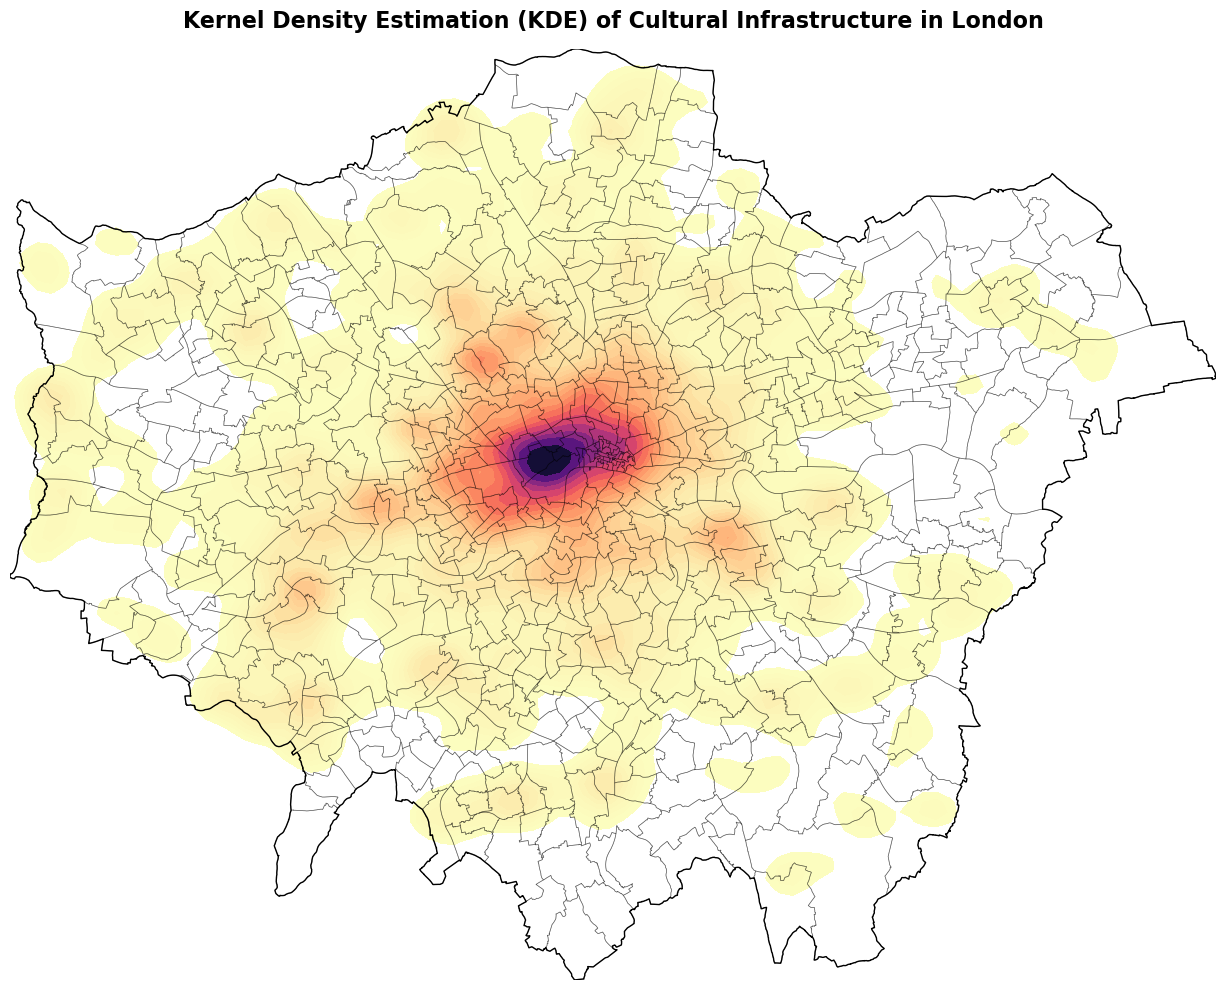

In [7]:
fig, ax = plt.subplots(figsize=(14, 10))

x = all_points.geometry.x
y = all_points.geometry.y

sns.kdeplot(
    x=x, y=y,
    cmap='magma_r',
    fill=True,
    levels=25,
    bw_adjust=0.6,  
    ax=ax,
    zorder=1
)

wards.plot(ax=ax, color='none', edgecolor='black', linewidth=0.5, alpha=0.4, zorder=2)

minx, miny, maxx, maxy = wards.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

london_boundary.plot(ax=ax, color='none', edgecolor='black', linewidth=1, zorder=2)

plt.title('Kernel Density Estimation (KDE) of Cultural Infrastructure in London', 
          fontsize=16, fontweight='bold', pad=15)
plt.axis('off') 
plt.tight_layout()

plt.show()

## NNI

In [8]:
coords = np.array(list(all_points.geometry.apply(lambda p: (p.x, p.y))))
n = len(coords)

# Calculate the actual average nearest-neighbour distance
tree = KDTree(coords)
distances, indices = tree.query(coords, k=2)
d_obs = distances[:, 1].mean()

# Calculate the expected average nearest-neighbour distance
A = london_boundary.geometry.area.sum()
d_exp = 0.5 / np.sqrt(n / A)

# Calculate the Nearest Neighbour Index (NNI)
nni = d_obs / d_exp

# Calculate the Z-score for a significance test
se = 0.26136 / np.sqrt((n**2) / A)
z_score = (d_obs - d_exp) / se

print(f"Total Points: {n} ")
print(f"Total area : {A / 1e6:.2f} sq km\n")
print(f"Actual Average Distance: {d_obs:.2f} metres")
print(f"Expected Average Distance: {d_exp:.2f} metres\n")
print(f"Nearest Neighbour Index (NNI): {nni:.4f}")
print(f"Z-Score: {z_score:.2f}")

print("")
if nni < 1 and z_score < -2.58:
    print("The NNI is significantly less than 1, and the Z-score indicates a confidence level greater than 99%.")
    print("Based on the NNI and Z-score tests, cultural infrastructures exhibit a strong spatially clustered distribution.")
elif nni > 1 and z_score > 2.58:
    print("The NNI is significantly greater than 1.")
    print("Based on the NNI and Z-score tests, cultural infrastructures exhibit a uniform/dispersed distribution.")
else:
    print("The NNI is close to 1 or the Z-score is not statistically significant.")
    print("Based on the NNI and Z-score tests, cultural infrastructures exhibit a random distribution.")

Total Points: 30001 
Total area : 1594.70 sq km

Actual Average Distance: 53.48 metres
Expected Average Distance: 115.28 metres

Nearest Neighbour Index (NNI): 0.4639
Z-Score: -177.63

The NNI is significantly less than 1, and the Z-score indicates a confidence level greater than 99%.
Based on the NNI and Z-score tests, cultural infrastructures exhibit a strong spatially clustered distribution.


## Ward level table

In [9]:
#Town Centres
tc_union = town_centres.geometry.unary_union

wards['is_town_centre'] = wards.geometry.intersects(tc_union)
wards['tc_status'] = wards['is_town_centre'].map({
    True: 'Town Centre', 
    False: 'Non-Town-Centre'
})

#PTALs
ward_centroids = wards.copy()
ward_centroids['geometry'] = ward_centroids.geometry.centroid

ptal_join = gpd.sjoin(ward_centroids, ptal, how='left', predicate='intersects')

ptal_join = ptal_join[~ptal_join.index.duplicated(keep='first')]

ptal_col_name = 'PTAL'

if ptal_col_name in ptal_join.columns:
    wards['ptal_class'] = ptal_join[ptal_col_name]
else:
    fallback_col = ptal.drop(columns='geometry').columns[0]
    wards['ptal_class'] = ptal_join[fallback_col]
    print(f"The column “{ptal_col_name}” was not found; “{fallback_col}” has been used as the PTAL placeholder.")

wards['ptal_class'] = wards['ptal_class'].fillna('Unknown')

# Create table
ward_code_col = 'GSS_CODE' if 'GSS_CODE' in wards.columns else wards.columns[0]
ward_name_col = 'NAME' if 'NAME' in wards.columns else wards.columns[1]

master_table = wards[[
    ward_code_col,
    ward_name_col,
    'area_sqkm',
    'culture_count',
    'culture_density',
    'tc_status',
    'ptal_class',
    'geometry' 
]].copy()

print(master_table.drop(columns='geometry').head())

    GSS_CODE                    NAME  area_sqkm  culture_count  \
0  E05000405       Chessington South   7.551784             10   
1  E05000414  Tolworth and Hook Rise   2.594673              1   
2  E05000401              Berrylands   1.453889             18   
3  E05000400               Alexandra   2.685017              2   
4  E05000402                Beverley   1.878205              9   

   culture_density        tc_status ptal_class  
0         1.324190  Non-Town-Centre         1b  
1         0.385405      Town Centre         1a  
2        12.380589  Non-Town-Centre         1a  
3         0.744874      Town Centre         1a  
4         4.791809      Town Centre          3  


## LISA

### LISA values

In [10]:
# Create a spatial weight matrix (Queen Contiguity)
w = lps.weights.Queen.from_dataframe(master_table)
w.transform = 'r'

# Extract key variables
y = master_table['culture_density'].values

# Caculate Local Moran's I
lisa = Moran_Local(y, w, seed=42)

sig_level = 0.05
sig_mask = lisa.p_sim < sig_level

# 1=HH, 2=LH, 3=LL, 4=HL
hh_count = sum((lisa.q == 1) & sig_mask)
lh_count = sum((lisa.q == 2) & sig_mask) # Low-High
ll_count = sum((lisa.q == 3) & sig_mask)
hl_count = sum((lisa.q == 4) & sig_mask) # High-Low

total_sig = sum(sig_mask)

print(f"LISA: (p < {sig_level})")
print(f"Total number of Wards: {len(master_table)}")
print(f"Wards with significant clustering: {total_sig}\n")
print(f"High-High: {hh_count} ")
print(f"Low-Low: {ll_count} ")
print(f"High-Low: {hl_count} ")
print(f"Low-High: {lh_count} ")
print(" ")

labels = ['Non-significant', 'High-High', 'Low-High', 'Low-Low', 'High-Low']
master_table['lisa_cluster'] = [labels[q] if sig else 'Non-significant' 
                                for q, sig in zip(lisa.q, sig_mask)]

LISA: (p < 0.05)
Total number of Wards: 657
Wards with significant clustering: 269

High-High: 72 
Low-Low: 195 
High-Low: 1 
Low-High: 1 
 


### LISA Cluster Map

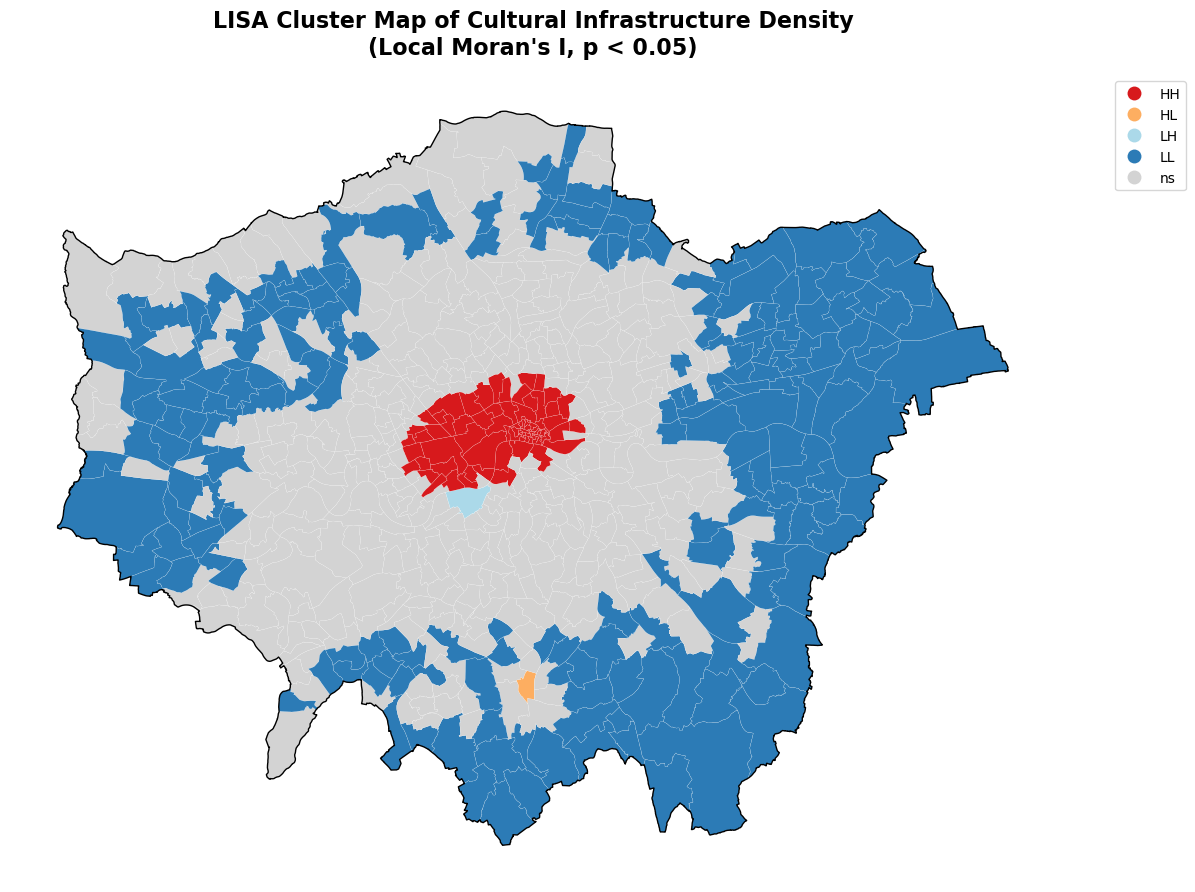

In [11]:
fig, ax = plt.subplots(figsize=(12, 10))

lisa_cluster(lisa, master_table, p=sig_level, ax=ax, 
             legend_kwds={'loc': 'upper left', 'bbox_to_anchor': (1.05, 1)})

london_boundary.plot(ax=ax, color='none', edgecolor='black', linewidth=1, zorder=2)

plt.title("LISA Cluster Map of Cultural Infrastructure Density\n(Local Moran's I, p < 0.05)", 
          fontsize=16, fontweight='bold', pad=15)
plt.axis('off')
plt.tight_layout()

plt.show()

**Note**: 

**HH (High-High)** indicates statistically significant clusters of high cultural density (hotspots).

**HL (High-Low)** indicates high-density spatial outliers surrounded by low-density neighbours.

**LH (Low-High)** indicates low-density spatial outliers surrounded by high-density neighbours.

**LL (Low-Low)** indicates statistically significant clusters of low cultural density (cold spots).

**ns** indicates no statistically significant spatial pattern.

## Category differences in cultural infrastructures

### Frequency table of all cultural infrastructure types

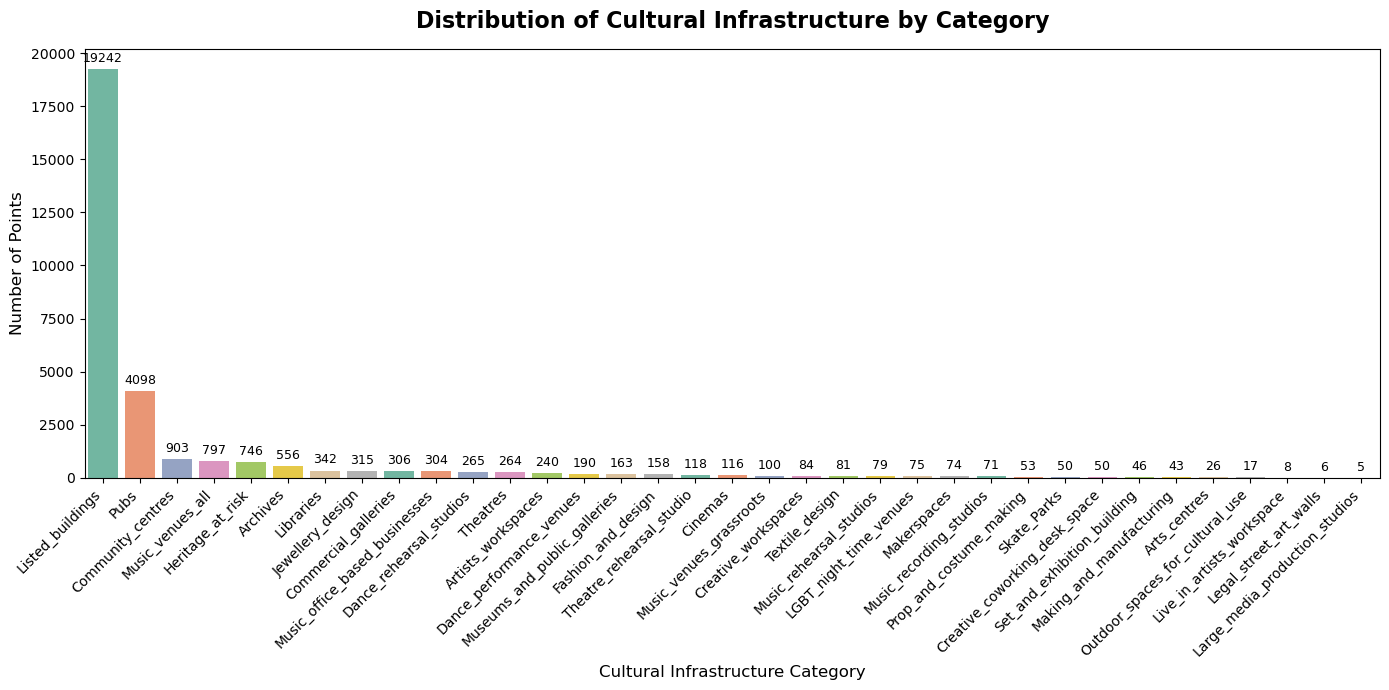

In [12]:
df_plot = pd.DataFrame({
    'Category': layer_names,
    'Count': layer_counts
}).sort_values(by='Count', ascending=False)

plt.figure(figsize=(14, 7))

ax = sns.barplot(data=df_plot, x='Category', y='Count', palette='Set2')

plt.title('Distribution of Cultural Infrastructure by Category', fontsize=16, pad=15, fontweight='bold')
plt.xlabel('Cultural Infrastructure Category', fontsize=12)
plt.ylabel('Number of Points', fontsize=12)

plt.xticks(rotation=45, ha='right', fontsize=10)

for i, v in enumerate(df_plot['Count']):
    ax.text(i, v + (df_plot['Count'].max() * 0.01), str(v), 
            ha='center', va='bottom', fontsize=9, color='black')

plt.tight_layout()
plt.show()

### Categorize cultural infrastructures into 5 main groups

### Define 5 main categories

In [13]:
category_dict = {
    'Heritage, Museums & Galleries': [
        'Heritage_at_risk', 'Listed_buildings', 'Museums_and_public_galleries', 
        'Commercial_galleries', 'Archives', 'Arts_centres'
    ],
    'Performing Arts & Nightlife Venues': [
        'Theatres', 'Dance_performance_venues', 'Cinemas', 'Music_venues_all', 
        'Music_venues_grassroots', 'LGBT_night_time_venues', 'Pubs'
    ],
    'Creative Workspaces & Production': [
        'Theatre_rehearsal_studio', 'Dance_rehearsal_studios', 'Music_rehearsal_studios', 
        'Music_recording_studios', 'Creative_workspaces', 'Creative_coworking_desk_space', 
        'Artists_workspaces', 'Live_in_artists_workspace', 'Makerspaces', 
        'Large_media_production_studios', 'Music_office_based_businesses'
    ],
    'Creative Manufacturing & Design': [
        'Set_and_exhibition_building', 'Textile_design', 'Fashion_and_design', 
        'Jewellery_design', 'Making_and_manufacturing', 'Prop_and_costume_making'
    ],
    'Civic, Community & Informal Culture': [
        'Community_centres', 'Libraries', 'Skate_Parks', 'Legal_street_art_walls', 
        'Outdoor_spaces_for_cultural_use'
    ]
}

all_wards = wards['NAME'].unique()

### Map

In [14]:
layer_to_cat = {layer: cat for cat, layers in category_dict.items() for layer in layers}

joined['Category_clean'] = joined['Category'].str.replace(' ', '_')
joined['Parent_Category'] = joined['Category_clean'].map(layer_to_cat)

pivot_df = pd.crosstab(joined['NAME'], joined['Parent_Category'])

all_wards = wards['NAME'].unique()
pivot_df = pivot_df.reindex(all_wards, fill_value=0)

### Top 10 wards for each of the 5 main categories (bar charts)

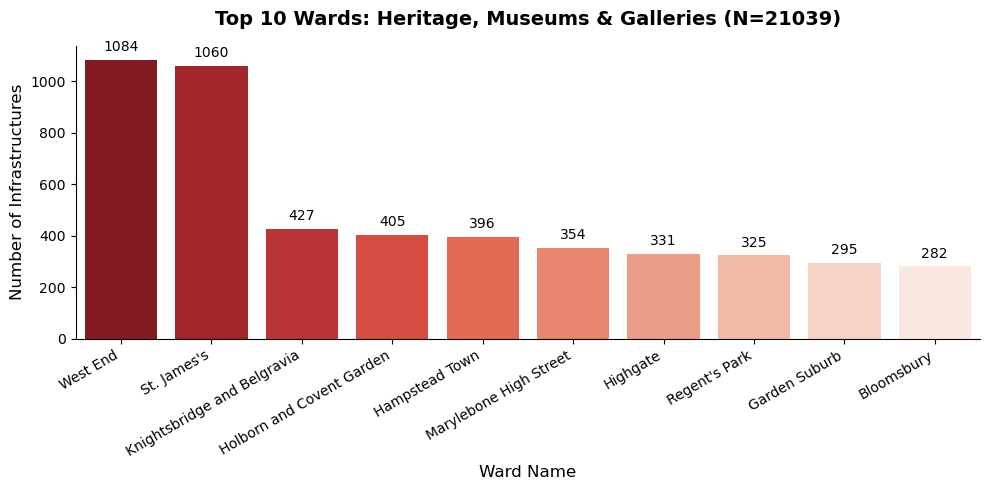

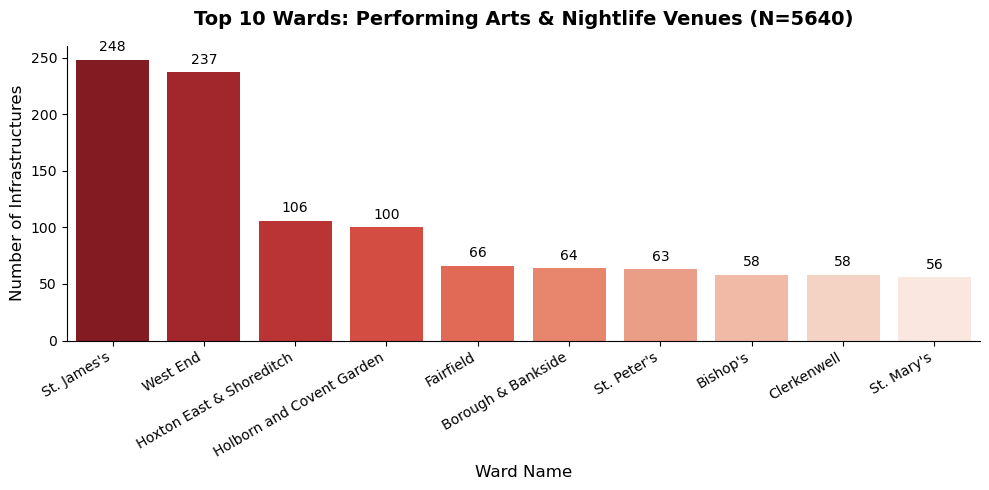

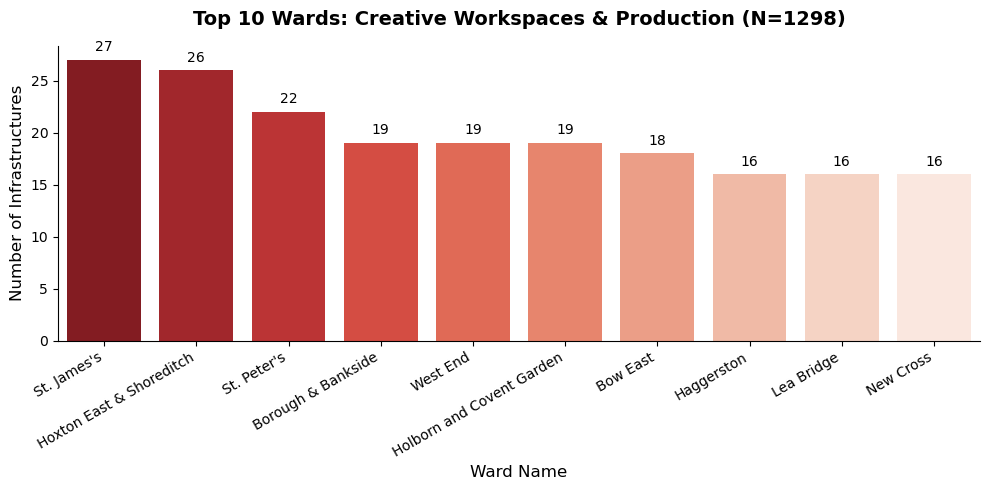

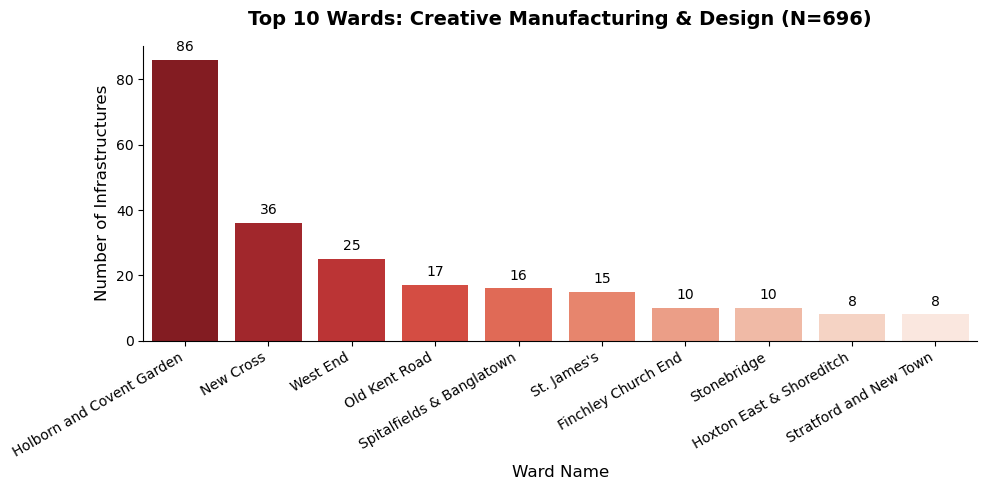

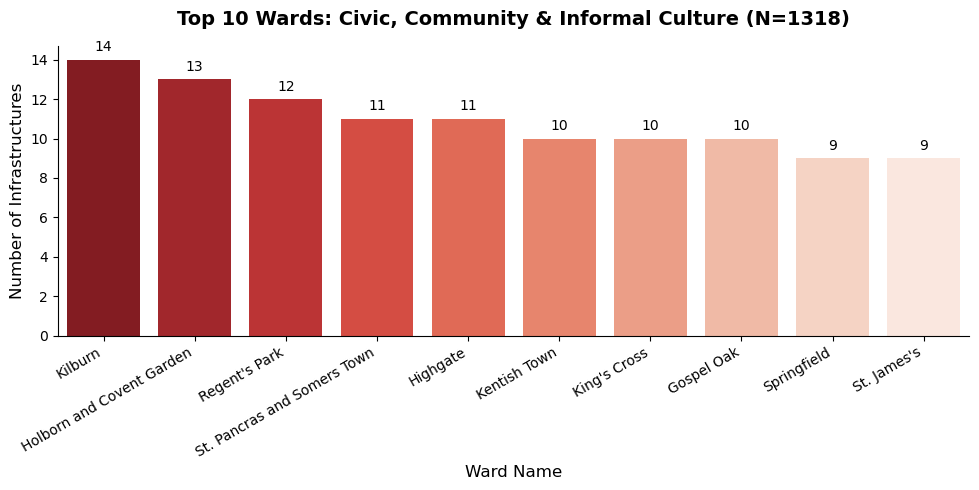

In [15]:
for cat in category_dict.keys():
    if cat in pivot_df.columns:
        total_n = pivot_df[cat].sum()
        
        top5 = pivot_df[[cat]].sort_values(by=cat, ascending=False).head(10).reset_index()
        top5.columns = ['NAME', 'Count']
        
        plt.figure(figsize=(10, 5))
        ax = sns.barplot(data=top5, x='NAME', y='Count', palette='Reds_r')
        
        plt.title(f'Top 10 Wards: {cat} (N={int(total_n)})', fontsize=14, fontweight='bold', pad=15)
        plt.xlabel('Ward Name', fontsize=12)
        plt.ylabel('Number of Infrastructures', fontsize=12)
        plt.xticks(rotation=30, ha='right', fontsize=10)
        
        for p in ax.patches:
            ax.text(p.get_x() + p.get_width() / 2., p.get_height() + (top5['Count'].max() * 0.02), 
                    f'{int(p.get_height())}', ha="center", va="bottom", fontsize=10)
            
        sns.despine()
        plt.tight_layout()
        plt.show()

### Spatial analysis of 'cultural deprivation'

In [16]:
lack_matrix = (pivot_df == 0).astype(int)
lack_score = lack_matrix.sum(axis=1)
lack_summary = pd.DataFrame({
    'NAME': lack_score.index, 
    'Lack_Score': lack_score.values
}).sort_values(by='Lack_Score', ascending=False)

#### Table 1: Wards with scores 4 and 5

In [17]:
print("Table 1: Most Culturally Deprived Wards (Scores: 4 and 5)")
high_deprivation = lack_summary[lack_summary['Lack_Score'] >= 4]

print(high_deprivation.to_markdown(index=False, tablefmt="fancy_grid"))
print("\n")

Table 1: Most Culturally Deprived Wards (Scores: 4 and 5)
╒════════════════════════╤══════════════╕
│ NAME                   │   Lack_Score │
╞════════════════════════╪══════════════╡
│ Newbury                │            5 │
├────────────────────────┼──────────────┤
│ Clementswood           │            5 │
├────────────────────────┼──────────────┤
│ Tolworth and Hook Rise │            4 │
├────────────────────────┼──────────────┤
│ Becontree              │            4 │
├────────────────────────┼──────────────┤
│ East Ham North         │            4 │
├────────────────────────┼──────────────┤
│ Shirley North          │            4 │
├────────────────────────┼──────────────┤
│ Longthornton           │            4 │
├────────────────────────┼──────────────┤
│ New Addington North    │            4 │
├────────────────────────┼──────────────┤
│ Norbury Park           │            4 │
├────────────────────────┼──────────────┤
│ Park Hill & Whitgift   │            4 │
├─────────────────

#### Table 2: Number of wards by score group

In [18]:
print("Table 2: Ward Count by Cultural Deprivation Score (0–5)")
score_counts = lack_summary['Lack_Score'].value_counts().sort_index(ascending=False).reset_index()
score_counts.columns = ['Lack_Score ', 'Number of Wards']

print(score_counts.to_markdown(index=False, tablefmt="fancy_grid"))
print("\n")

Table 2: Ward Count by Cultural Deprivation Score (0–5)
╒═══════════════╤═══════════════════╕
│   Lack_Score  │   Number of Wards │
╞═══════════════╪═══════════════════╡
│             5 │                 2 │
├───────────────┼───────────────────┤
│             4 │                14 │
├───────────────┼───────────────────┤
│             3 │                60 │
├───────────────┼───────────────────┤
│             2 │               199 │
├───────────────┼───────────────────┤
│             1 │               219 │
├───────────────┼───────────────────┤
│             0 │               144 │
╘═══════════════╧═══════════════════╛




#### Map 3: Spatial distribution of 0–5 deprivation scores

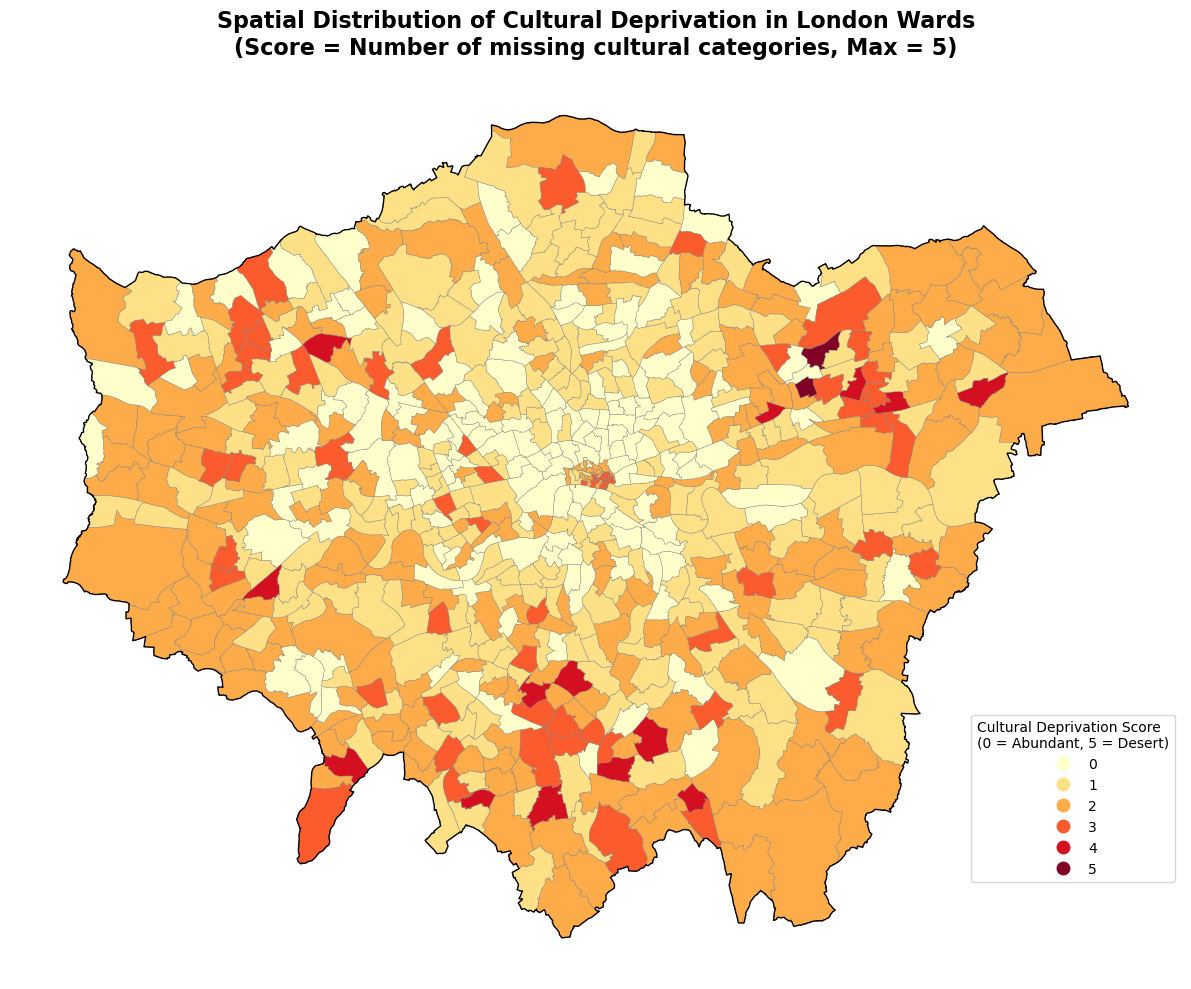

In [19]:
wards_map = wards.merge(lack_summary, on='NAME', how='left')

fig, ax = plt.subplots(figsize=(14, 10))

wards_map.plot(
    column='Lack_Score',
    cmap='YlOrRd',          
    linewidth=0.3,
    edgecolor='grey',
    legend=True,
    categorical=True,       
    legend_kwds={
        'title': 'Cultural Deprivation Score\n(0 = Abundant, 5 = Desert)', 
        'loc': 'lower right',
        'bbox_to_anchor': (1, 0.1)
    },
    ax=ax
)

london_boundary.plot(ax=ax, color='none', edgecolor='black', linewidth=1, zorder=2)

plt.title('Spatial Distribution of Cultural Deprivation in London Wards\n(Score = Number of missing cultural categories, Max = 5)', 
          fontsize=16, fontweight='bold', pad=15)

plt.axis('off')
plt.tight_layout()
plt.show()

## Bivariate Choropleth Map

### Identify wards inside/outside Town Centres

In [20]:
tc_union = town_centres.geometry.unary_union

intersection_geoms = wards.geometry.intersection(tc_union)
wards['tc_intersect_area'] = intersection_geoms.area

wards['town_centre_share'] = wards['tc_intersect_area'] / wards.geometry.area

wards['tc_status'] = wards['town_centre_share'].apply(
    lambda x: 'Town Centre' if x >= 0.10 else 'Non-Town-Centre'
)

if 'master_table' in locals():
    cols_to_drop = [col for col in ['tc_status', 'town_centre_share'] if col in master_table.columns]
    if cols_to_drop:
        master_table = master_table.drop(columns=cols_to_drop)
        
    master_table = master_table.merge(
        wards[['NAME', 'tc_status', 'town_centre_share']], 
        on='NAME', 
        how='left'
    )

In [21]:
zero_overlap = (wards['town_centre_share'] == 0).sum()
edge_overlap = ((wards['town_centre_share'] > 0) & (wards['town_centre_share'] < 0.10)).sum()
core_tc = (wards['town_centre_share'] >= 0.10).sum()

print(f"0% Cover: {zero_overlap}")
print(f"0%-10% Cover: {edge_overlap} , classified as [Non-Town-Centre]")
print(f"≥ 10% Cover: {core_tc} , classified as [Town Centre]")

0% Cover: 190
0%-10% Cover: 395 , classified as [Non-Town-Centre]
≥ 10% Cover: 72 , classified as [Town Centre]


### Reclassification

In [22]:
# PTAL
ptal_mapping = {
    '0': 1, '1a': 1, '1b': 1, '2': 1, '2a':1, '2b':1, 
    '3': 2, '4': 2,
    '5': 3, '6a': 3, '6b': 3, '6': 3
}
master_table['ptal_class'] = master_table['ptal_class'].astype(str).map(ptal_mapping).fillna(0).astype(int)

# Cultural Density 
k = 3
density_classifier = mc.Quantiles(master_table['culture_density'], k=k)
master_table['density_class'] = density_classifier.yb + 1

### Create 3×3 bivariate colormap and identify Town Centre wards

In [23]:
bivariate_colors = {
    '1-1': '#e8e8e8',
    '2-1': '#b0d5df',
    '3-1': '#64acbe',
    
    '1-2': '#e4acac',
    '2-2': '#ad9ea5',
    '3-2': '#627f8c',
    
    '1-3': '#c85a5a',
    '2-3': '#985356',
    '3-3': '#574249'
}

master_table['biv_class'] = master_table['ptal_class'].astype(str) + '-' + master_table['density_class'].astype(str)

master_table['color'] = master_table['biv_class'].map(bivariate_colors).fillna('#ffffff')

tc_wards = master_table[master_table['tc_status'] == 'Town Centre']
non_tc_wards = master_table[master_table['tc_status'] == 'Non-Town-Centre']

### Visualisation

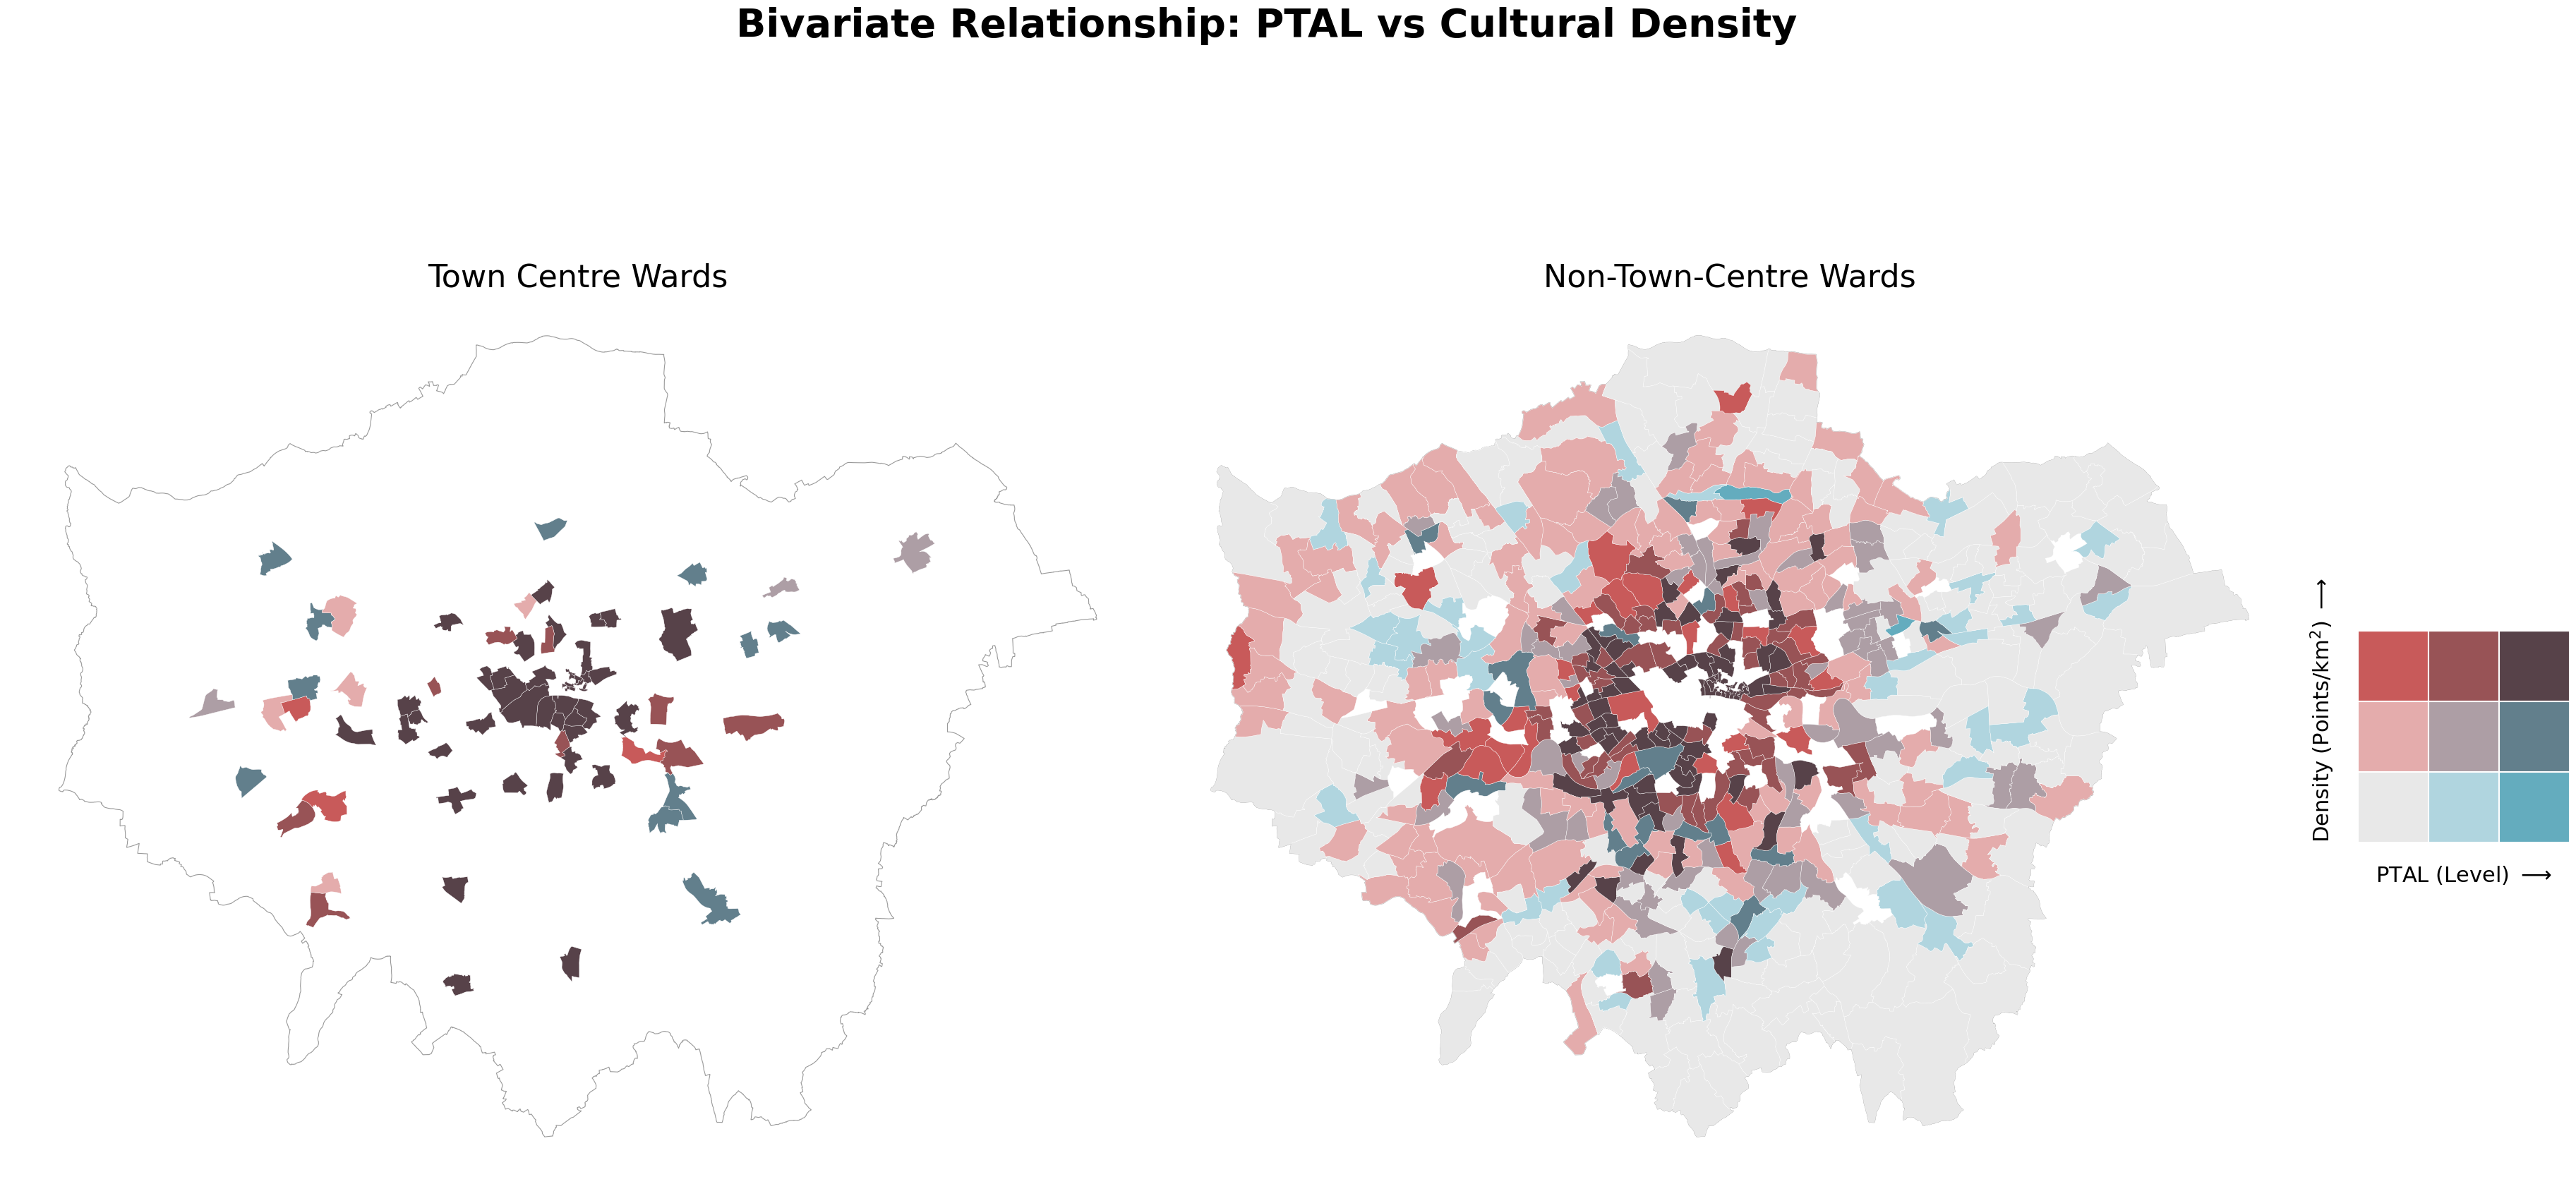

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(40, 20))
fig.suptitle('Bivariate Relationship: PTAL vs Cultural Density', 
             fontsize=40, fontweight='bold', x=0.45, y=0.95)

# Town Centre Wards
london_boundary.plot(ax=ax1, color='none', edgecolor='#999999', linewidth=0.8, zorder=1)
tc_wards.plot(ax=ax1, color=tc_wards['color'], edgecolor='white', linewidth=0.3, zorder=2)
ax1.set_title('Town Centre Wards', fontsize=32, pad=10)
ax1.axis('off')

# Non-Town-Centre Wards
london_boundary.plot(ax=ax2, color='none', edgecolor='#999999', linewidth=0.8, zorder=1)
non_tc_wards.plot(ax=ax2, color=non_tc_wards['color'], edgecolor='white', linewidth=0.3, zorder=2)
ax2.set_title('Non-Town-Centre Wards', fontsize=32, pad=10)
ax2.axis('off')

ax_legend = inset_axes(ax2, width=3, height=3, loc='center left',
                       bbox_to_anchor=(1.05, 0.5),
                       bbox_transform=ax2.transAxes, borderpad=0)
ax_legend.set_aspect('equal')

for i in range(1, 4):
    for j in range(1, 4): 
        code = f"{j}-{i}"
        rect = Rectangle((j-1, i-1), 1, 1, facecolor=bivariate_colors[code], edgecolor='white', lw=1.5)
        ax_legend.add_patch(rect)

ax_legend.set_xlim(0, 3)
ax_legend.set_ylim(0, 3)
ax_legend.axis('off') 

ax_legend.text(1.5, -0.3, r'PTAL (Level) $\longrightarrow$', 
               ha='center', va='top', fontsize=22)
ax_legend.text(-0.5, 0.0, r'Density (Points/km$^2$) $\longrightarrow$', 
               ha='center', va='bottom', rotation=90, fontsize=22)

plt.tight_layout(rect=[0, 0, 0.82, 0.9]) 
plt.show()

### Spatial Error Model

In [25]:
master_table = master_table.drop_duplicates(subset=['GSS_CODE']).reset_index(drop=True)

master_table['log_culture_density'] = np.log1p(master_table['culture_density'])
master_table['is_tc'] = (master_table['tc_status'] == 'Town Centre').astype(int)

w = lps.weights.Queen.from_dataframe(master_table)
w.transform = 'r'

master_table['ptal_2'] = (master_table['ptal_class'] == 2).astype(int)
master_table['ptal_3'] = (master_table['ptal_class'] == 3).astype(int)

master_table['tc_x_ptal2'] = master_table['is_tc'] * master_table['ptal_2']
master_table['tc_x_ptal3'] = master_table['is_tc'] * master_table['ptal_3']

y_var = master_table[['log_culture_density']].values
x_names = ['is_tc', 'ptal_2', 'ptal_3', 'tc_x_ptal2', 'tc_x_ptal3']
x_vars = master_table[x_names].values

sem_model = spreg.GM_Error_Het(y_var, x_vars, w=w, name_y='log_culture_density', name_x=x_names, name_ds='London_Wards')

print(sem_model.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: GM SPATIALLY WEIGHTED LEAST SQUARES (HET)
------------------------------------------------------------
Data set            :London_Wards
Weights matrix      :     unknown
Dependent Variable  :log_culture_density                Number of Observations:         657
Mean dependent var  :      2.7042                Number of Variables   :           6
S.D. dependent var  :      1.3965                Degrees of Freedom    :         651
Pseudo R-squared    :      0.4604
N. of iterations    :           1                Step1c computed       :          No

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------------------------------------------------------------------------------
            CONSTANT         2.35734         0.15229        15.47968         0.00000
               is_tc         0.68830         0.25